#  Food-101 Classification: Deep Transfer Learning Pipeline

This notebook documents the end-to-end training and evaluation pipeline for classifying images across all **101 culinary categories** in the Food-101 benchmark.

Instead of training a vision model from scratch on 75,000+ images, i leverage **transfer learning with EfficientNet-B3**. The goal is to build an accurate, lightweight classifier capable of producing reliable confidence scores for deployment in a real-time Streamlit web app.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
from torch import nn
from torch.utils.data import Dataset , DataLoader
import torchvision
from torchvision import transforms
from torchvision import datasets

import torchvision.models as models

from food101_dataset import get_dataset
from food101_model import get_model

In [4]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


## 1. Data Augmentation & Sanity Checks

Food imagery presents distinct computer vision challenges: real-world user photos vary wildly in camera angles, portion sizes, plate styles, and ambient dining lighting.

To prevent early overfitting, we apply a robust augmentation pipeline:
- **Random Horizontal & Vertical Flips ($p=0.5$):** Dishes generally retain their identity regardless of orientation.
- **Random Rotations ($\pm 30^\circ$):** Simulates imperfect handheld smartphone photography.
- **Color Jitter (Brightness, Contrast, Saturation, Hue):** Accounts for varying restaurant lighting (harsh fluorescent bulbs vs. dim candlelight).
- **ImageNet Normalization:** Normalizes channel distributions using standard mean `[0.485, 0.456, 0.406]` and std `[0.229, 0.224, 0.225]` to align with pretrained weights.

*Note: Below, we un-normalize a random batch ($X = X_{norm} \times \sigma + \mu$) to visually verify that our augmentations preserve identifiable dish textures without distortion.*

In [5]:
train_dataset,test_dataset=get_dataset()

100%|██████████| 5.00G/5.00G [03:36<00:00, 23.1MB/s]


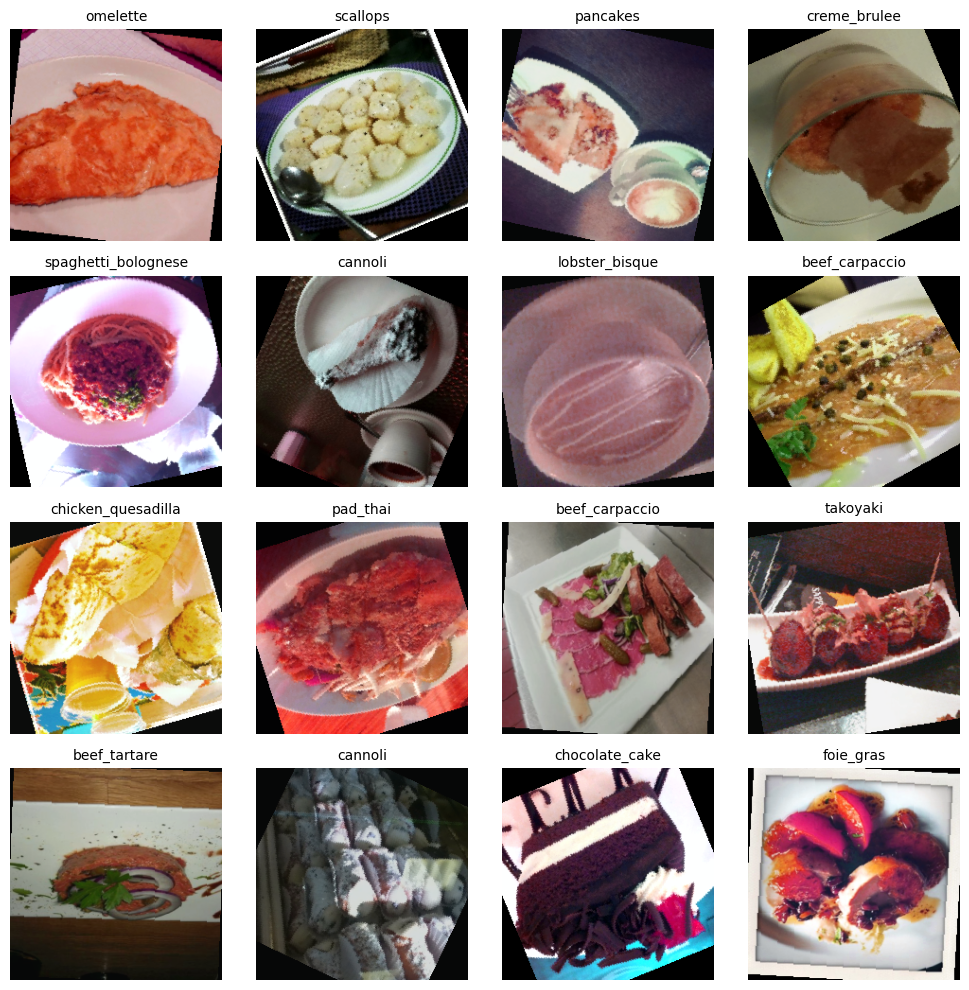

In [6]:
plt.figure(figsize=(10,10))
for i in range (16):
  idx=random.randint(0,len(train_dataset)-1)
  img,label=train_dataset[idx]
  class_name=train_dataset.classes[label]

  plt.subplot(4,4,i+1)

  img_np = img.permute(1, 2, 0).numpy()
  # same values of meas and std be used to normalize this dataset with
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])

  # Un-normalize (Math: X = X_norm * std + mean) (we are now un-normalize a the images we got from the dataset for better visualization)
  img_np = std * img_np + mean
  img_np = np.clip(img_np, 0, 1) # Force any weird floating point stragglers into [0, 1]

  plt.imshow(img_np)
  plt.title(class_name, fontsize=10)
  plt.axis('off')

plt.tight_layout()   #Adjusts spacing
plt.show()

In [7]:
BATCH_SIZE=64

train_dataloader=DataLoader(
                            dataset=train_dataset,
                            batch_size=BATCH_SIZE,
                            num_workers=2,
                            pin_memory=True,
                            shuffle=True
                            )
test_dataloader=DataLoader(
                           dataset=test_dataset,
                           batch_size=BATCH_SIZE,
                           num_workers=2,
                           pin_memory=True,
                           shuffle=False
                           )

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7a69e5620590>,
 <torch.utils.data.dataloader.DataLoader at 0x7a69e5424e10>)

In [8]:
img_batch,label_batch=next(iter(train_dataloader))
img_batch.shape,label_batch.shape

(torch.Size([64, 3, 224, 224]), torch.Size([64]))

## 2. Model Architecture & Fine-Tuning Strategy

### Why EfficientNet-B3?
Traditional convolutional architectures scale arbitrarily—increasing depth (ResNet), width (WideResNet), or input resolution. EfficientNet relies on **compound scaling**, balancing depth, width, and resolution with a fixed scaling coefficient.

`EfficientNet-B3` hits the sweet spot for Food-101:
- It maintains a manageable parameter count (~12M base parameters), enabling rapid training loops on a standard GPU (T4).
- Its receptive field captures both high-level plate arrangements and fine-grained garnish/sauce textures far better than smaller baselines like ResNet-18 or EfficientNet-B0.

### The Fine-Tuning
1. **Feature Freezing:** Freeze base layers (`features[0]` through `features[6]`) to preserve general low-level edge, gradient, and texture representations learned from ImageNet.
2. **Custom Classification Head:** Replace the original 1,000-class head with a custom multilayer projection:
   $$\text{Linear}(1536 \rightarrow 256) \rightarrow \text{ReLU} \rightarrow \text{Dropout}(0.3) \rightarrow \text{Linear}(256 \rightarrow 128) \rightarrow \text{ReLU} \rightarrow \text{Dropout}(0.3) \rightarrow \text{Linear}(128 \rightarrow 101)$$
   The layered bottleneck compresses high-dimensional representations while dropout prevents co-adaptation.
3. **Selective Layer Unfreezing:** Unfreeze the final two convolutional blocks (`features[7]` and `features[8]`). This allows high-level abstraction filters to adapt specifically to food structures without corrupting foundational feature extractors.

In [10]:
efficientnet_model=get_model(device=device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 191MB/s]


## 3. Training Setup & Optimization

- **Loss Function:** `nn.CrossEntropyLoss()` combines Softmax normalization with negative log-likelihood.
- **Optimizer:** `torch.optim.Adam` initialized with a learning rate of $10^{-3}$ for steady convergence across the unfrozen head and final blocks.
- **Metric Tracking:** Rather than computing batch-level averages that skew over uneven batch sizes, we use `torchmetrics` (`Accuracy`, `Precision`, `Recall`) set to `task='multiclass'` over 101 classes. Metrics accumulate states across batches and compute true global statistics at epoch boundaries before resetting.

In [11]:
!pip -q install torchmetrics
import torchmetrics as tm
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=efficientnet_model.parameters(),lr=0.001)

accuracy=tm.Accuracy(task='multiclass',num_classes=101).to(device)
recall=tm.Recall(task='multiclass',num_classes=101).to(device)
precision=tm.Precision(task='multiclass',num_classes=101).to(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.7 MB/s eta 0:00:00


In [ ]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

start_time=timer()

epochs=10
plt_epochs=[]
plt_train_loss=[]
plt_train_accuracy=[]
plt_train_recall=[]
plt_train_precision=[]

for epoch in tqdm(range(epochs)):
  efficientnet_model.train()
  train_loss=0

  for batch,(X,y) in enumerate(train_dataloader):
    X,y=X.to(device),y.to(device)

    y_pred=efficientnet_model(X)

    loss=loss_fn(y_pred,y)
    train_loss+=loss.item()

    accuracy.update(y_pred, y)
    precision.update(y_pred, y)
    recall.update(y_pred, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  plt_epochs.append(epoch)
  train_loss /= len(train_dataloader)

  # Compute the final metrics ONCE at the end of the epoch
  epoch_accuracy = accuracy.compute().item()
  epoch_precision = precision.compute().item()
  epoch_recall = recall.compute().item()

  accuracy.reset()
  precision.reset()
  recall.reset()

  #appending the avg train_loss etc to there respected list for ploting
  plt_train_loss.append(train_loss)
  plt_train_accuracy.append(epoch_accuracy)
  plt_train_recall.append(epoch_recall)
  plt_train_precision.append(epoch_precision)

  torch.save(efficientnet_model.state_dict(), f'efficientnet_epoch_{ecophs+1}.pth')
  print(f"\n--------------- Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_accuracy: {epoch_accuracy:.4f} | train_recall: {epoch_recall:.4f} | train_precision: {epoch_precision:.4f} ---------------\n")

end_time=timer()
total_time=end_time-start_time
print(f"Total Training Time: {(total_time:.3f)/60} minutes")


  0%|          | 0/10 [00:00<?, ?it/s]


--------------- Epoch: 1 | train_loss: 2.7936 | train_accuracy: 0.2973 | train_recall: 0.2973 | train_precision: 0.2973 ---------------


--------------- Epoch: 2 | train_loss: 2.2808 | train_accuracy: 0.4360 | train_recall: 0.4360 | train_precision: 0.4360 ---------------


--------------- Epoch: 3 | train_loss: 2.0916 | train_accuracy: 0.4826 | train_recall: 0.4826 | train_precision: 0.4826 ---------------


--------------- Epoch: 4 | train_loss: 1.9657 | train_accuracy: 0.5102 | train_recall: 0.5102 | train_precision: 0.5102 ---------------


--------------- Epoch: 5 | train_loss: 1.8864 | train_accuracy: 0.5297 | train_recall: 0.5297 | train_precision: 0.5297 ---------------


--------------- Epoch: 6 | train_loss: 1.8302 | train_accuracy: 0.5450 | train_recall: 0.5450 | train_precision: 0.5450 ---------------


--------------- Epoch: 7 | train_loss: 1.7756 | train_accuracy: 0.5563 | train_recall: 0.5563 | train_precision: 0.5563 ---------------


--------------- Epoch: 8 | train_

In [14]:
test_loss = 0.0
test_acc = 0.0

efficientnet_model.eval()
with torch.inference_mode():
    for X_test, y_test in test_dataloader:
        X_test, y_test = X_test.to(device), y_test.to(device)

        test_pred = efficientnet_model(X_test)

        loss = loss_fn(test_pred, y_test).item()
        test_loss += loss

        accuracy.update(test_pred, y_test)
        precision.update(test_pred, y_test)
        recall.update(test_pred, y_test)

    test_acc = accuracy.compute().item()
    test_loss = test_loss/len(test_dataloader)
    test_precision = precision.compute().item()
    test_recall = recall.compute().item()

    accuracy.reset()
    precision.reset()
    recall.reset()

print(f"\nFinal Test Loss: {test_loss:.4f} | Final Test Acc: {test_acc * 100:.2f}%")


Final Test Loss: 1.0705 | Final Test Acc: 71.24%


## 4. Evaluation & Generalization Analysis

Evaluating the fine-tuned checkpoint across the full 25,250-image test set yields:
- **Final Test Loss:** `1.0705`
- **Final Test Accuracy:** `71.24%`

### Key Takeaways:
- **Strong Generalization:** Achieving ~71% top-1 accuracy on 101 fine-grained classes with only 10 epochs demonstrates that selective layer unfreezing prevents catastrophic forgetting while learning nuanced culinary differences.
- **Convergence Behavior:** The loss and metric curves confirm steady optimization without divergence. The gradual leveling off of training loss around epoch 8–10 indicates the model has extracted the majority of available predictive variance from the current learning rate schedule.
- **Ready for Export:** We serialize the model `state_dict` and save the alphabetical class labels as `food101_classes.json` to feed directly into the Streamlit inference engine.

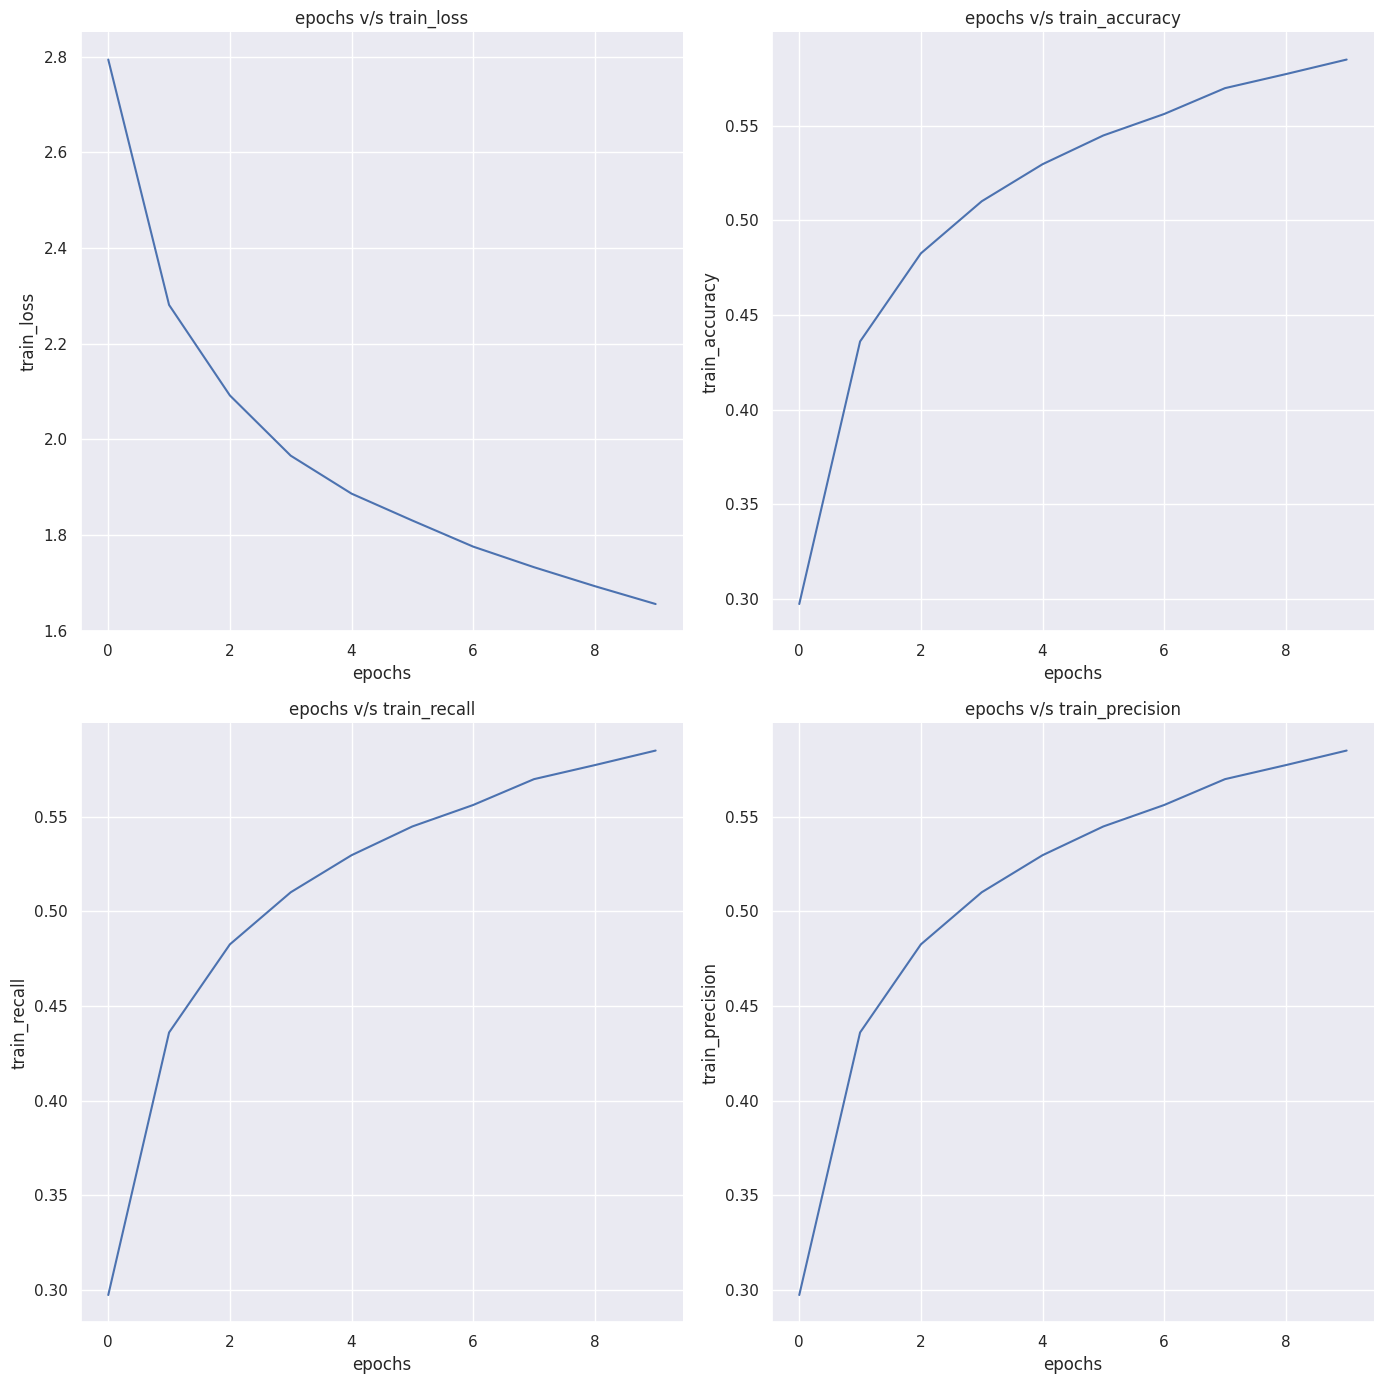

In [ ]:
plt.figure(figsize=(14,14))
sns.set_theme(style='darkgrid')
plt.subplot(2,2,1)
plt.title("epochs v/s train_loss")
sns.lineplot(x=plt_epochs,y=plt_train_loss)
plt.xlabel('epochs')
plt.ylabel('train_loss')

plt.subplot(2,2,2)
plt.title("epochs v/s train_accuracy")
sns.lineplot(x=plt_epochs,y=plt_train_accuracy)
plt.xlabel('epochs')
plt.ylabel('train_accuracy')

plt.subplot(2,2,3)
plt.title("epochs v/s train_recall")
sns.lineplot(x=plt_epochs,y=plt_train_recall)
plt.xlabel('epochs')
plt.ylabel('train_recall')

plt.subplot(2,2,4)
plt.title("epochs v/s train_precision")
sns.lineplot(x=plt_epochs,y=plt_train_precision)
plt.xlabel('epochs')
plt.ylabel('train_precision')

plt.tight_layout()
sns.despine()
plt.show()

<Figure size 1600x1600 with 0 Axes>

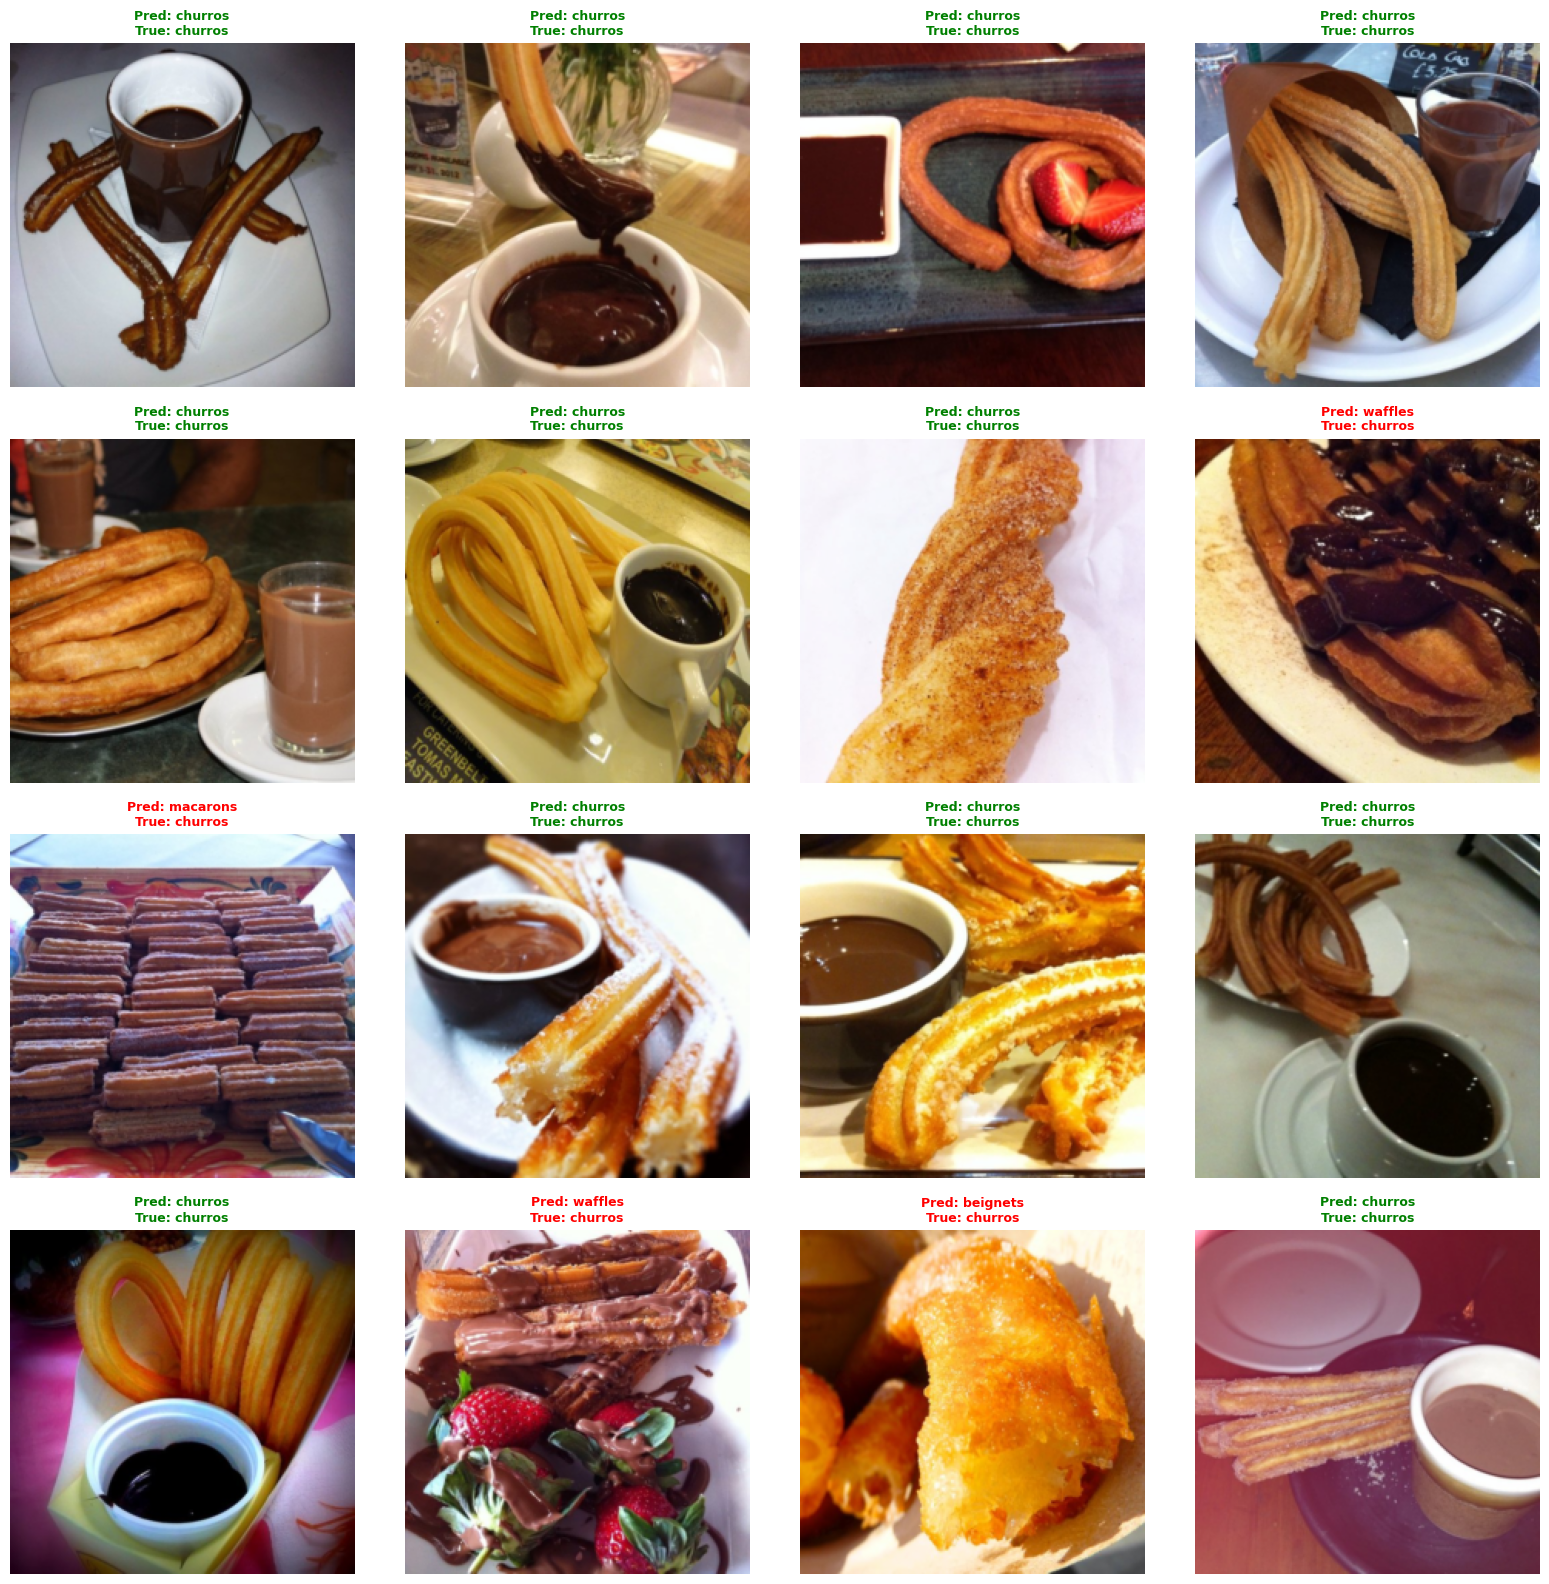

In [28]:
from matplotlib import axes
import random

#Geting img_batch and label batch than making prediction on those
img_batch,label_batch=next(iter(test_dataloader))

efficientnet_model.eval()
with torch.inference_mode():
  img_batch=img_batch.to(device)
  pred_logits=efficientnet_model(img_batch)
  pred_probs=torch.softmax(pred_logits,dim=1)
  pred_labels=torch.argmax(pred_probs,dim=1)

#Ploting image with predicted class and true class
sns.set_theme(style='darkgrid')

sample_indices=random.sample(range(len(img_batch)),k=16)
fig,axes=plt.subplots(nrows=4,ncols=4,figsize=(16,16))
axes=axes.flatten()

for i,ax in enumerate(axes):
  img=img_batch[sample_indices[i]].permute(1,2,0).cpu().numpy()
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  img = std * img + mean
  img = np.clip(img, 0, 1)

  ax.imshow(img)

  pred_class=train_dataset.classes[pred_labels[sample_indices[i]]]
  true_class=train_dataset.classes[label_batch[sample_indices[i]]]

  title_color = "green" if pred_class==true_class else "red"
  ax.set_title(
               f"Pred: {pred_class}\nTrue: {true_class}",
               color=title_color,
               fontsize=9,
               fontweight="bold"
               )
  ax.axis('off')

plt.tight_layout()

sns.despine()
plt.show()

In [ ]:
torch.save(efficientnet_model.state_dict(), f'final_efficientnet_epoch.pth')

In [ ]:
import json

with open("food101_classes.json", "w") as f:
    json.dump(train_dataset.classes, f)

print("Export complete!")

Export complete!
